# **Data analisis Bachelor's project**

### Summary of incoming data

| Name | Num of classes | Num of Photos |
|---|---:|---:|
| `Data_K` | 29 | 2900 |
| `Data_R` | 29 | 2900 |
| `Data_O` | 28 | 2800 |

Data_for_alphabet_prop is only used for display purposes as an example, models are not trained on it

## Data analisis

Installing libraries and getting data

In [39]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import os
import numpy as np
from collections import Counter
import pickle

In [4]:
DATASET_K = 'C:/Projects/Bachelors/Data/Data_alphabet_K'
DATASET_O = 'C:/Projects/Bachelors/Data/Data_alphabet_O'
DATASET_R = "C:/Projects/Bachelors/Data/Data_alphabet_R"

DATASET_Display = 'C:/Projects/Bachelors/Data/Data_for_alphabet_prop'

In [40]:
KEYPOINTS_K = 'C:/Projects/Bachelors/Data/Keypoints_K.pickle'
KEYPOINTS_R = 'C:/Projects/Bachelors/Data/Keypoints_R.pickle'
KEYPOINTS_O = 'C:/Projects/Bachelors/Data/Keypoints_O.pickle'

In [43]:
datasets = {
    "K": DATASET_K,
    "O": DATASET_O,
    "R": DATASET_R,
}

pickle_files = {
    "K": KEYPOINTS_K,
    "O": KEYPOINTS_O,
    "R": KEYPOINTS_R,
}

colors = {
    "K": "#FF6B00",
    "O": "#6C00FF",
    "R": "#00FF99",
}

Creating function to load images (use example on DATASET_Display)

In [17]:
def load_images(folder, max_images=9):
    images = []
    labels = []
    
    for label in os.listdir(folder):
        label_path = os.path.join(folder, label)
        
        if not os.path.isdir(label_path):
            continue
            
        for img_name in os.listdir(label_path)[:max_images]:
            img_path = os.path.join(label_path, img_name)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)
                labels.append(label)
    
    return images, labels

images_Dis, labels_Dis = load_images(DATASET_Display)

In [19]:
images_K, labels_K = load_images(DATASET_K)
images_O, labels_O = load_images(DATASET_O)
images_R, labels_R = load_images(DATASET_R)

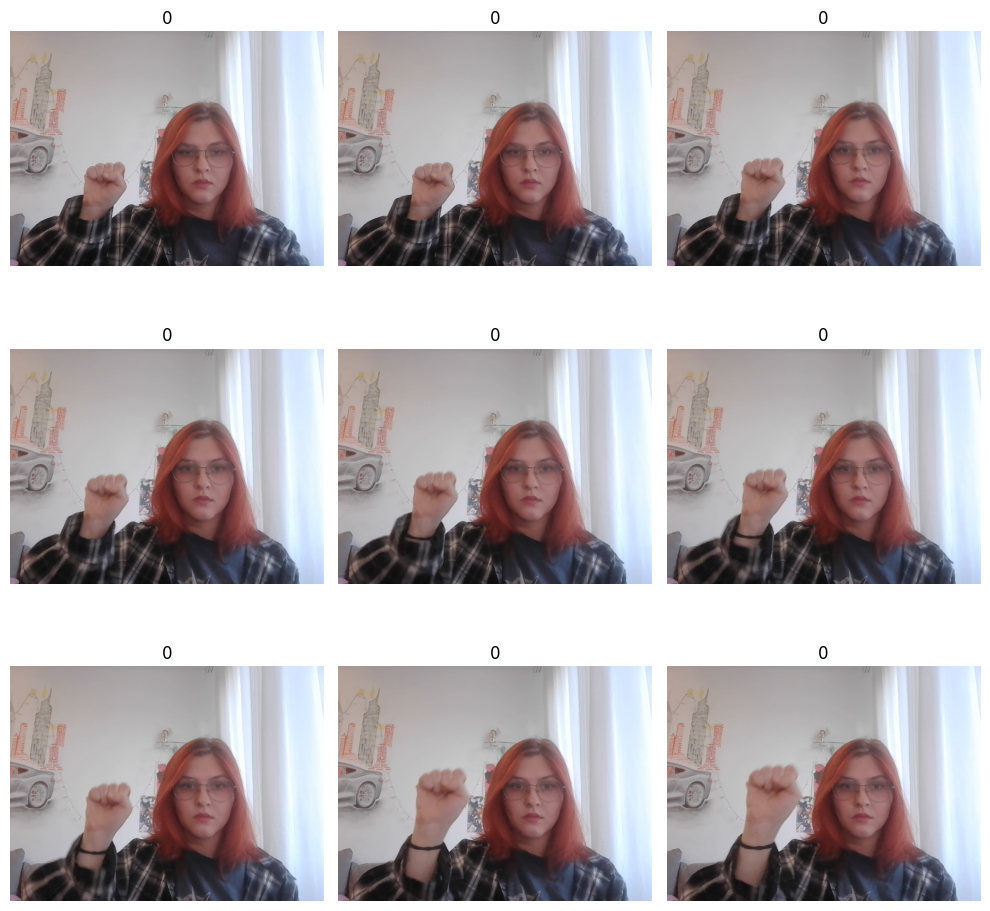

In [18]:
plt.figure(figsize=(10,10))

for i in range(min(len(images_Dis), 9)):
    plt.subplot(3, 3, i+1)
    plt.imshow(images_Dis[i])
    plt.title(labels_Dis[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Brightness

In [ ]:
def image_brightness(images):
    brightness_values = []

    for image in images:
        grayscale = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        brightness_values.append(float(grayscale.mean()))

    return np.array(brightness_values)


brightness_K = image_brightness(images_K)
brightness_O = image_brightness(images_O)
brightness_R = image_brightness(images_R)

In [21]:
print(brightness_K)

[102.01580625 102.08428333 102.33334167 103.32890417 103.79360208
 104.17679375 104.38249375 104.523575   104.523575    97.19583125
  97.19583125  98.17379375  98.65050625  99.29933125  99.65556042
 100.06849375 100.45848542 100.74958542 100.23245833 100.23245833
 101.72792708 102.16339792 102.53531667 102.53531667 102.86950208
 103.13749167 103.39901667 100.93888958 101.00507083 102.76681458
 103.50322917 104.26762708 104.26762708 105.03009583 105.53677708
 105.93926042  95.60922917  95.65986667  98.71012708  98.71012708
  99.51059167 100.1906     100.1906     100.76247708 101.23315625
  99.49159792  99.63333333 104.1015375  104.6206875  105.14271875
 105.14271875 105.74497083 106.39338542 107.73755833  99.01805833
  99.22182917 102.51534375 102.51534375 103.19833958 103.85627292
 104.38253542 104.38253542 104.77646667  94.29404375  94.28863958
  96.55021875  96.55021875  97.61412917  98.53995625  98.53995625
  99.15828333  99.71958542 102.40828125 102.60933125 106.20095417
 107.00336

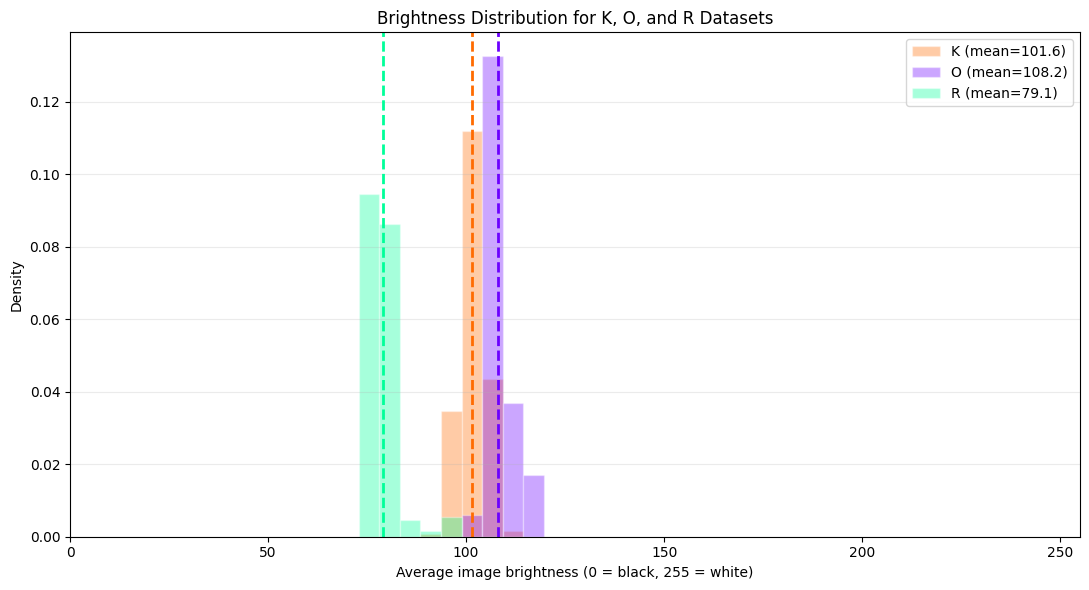

In [ ]:
brightness_sets = {
    "K": brightness_K,
    "O": brightness_O,
    "R": brightness_R,
}

plt.figure(figsize=(11, 6))
bins = np.linspace(0, 255, 50)

for label, values in brightness_sets.items():
    plt.hist(
        values,
        bins=bins,
        alpha=0.35,
        density=True,
        color=colors[label],
        edgecolor="white",
        label=f"{label} (mean={values.mean():.1f})",
    )
    plt.axvline(values.mean(), color=colors[label], linestyle="--", linewidth=2)

plt.title("Brightness Distribution for K, O, and R Datasets")
plt.xlabel("Average image brightness (0 = black, 255 = white)")
plt.ylabel("Density")
plt.xlim(0, 255)
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
def sort_key(value):
    stem = os.path.splitext(value)[0]
    return (0, int(stem)) if stem.isdigit() else (1, stem)

def get_brightness_from_path(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.mean(gray)


def load_metadata(folder, max_images=None):
    paths, labels, brightness = [], [], []

    for label in sorted(os.listdir(folder), key=sort_key):
        label_path = os.path.join(folder, label)
        if not os.path.isdir(label_path):
            continue

        files = sorted(os.listdir(label_path), key=sort_key)
        if max_images:
            files = files[:max_images]

        for img_name in files:
            img_path = os.path.join(label_path, img_name)
            if not img_name.lower().endswith((".jpg")):
                continue

            b = get_brightness_from_path(img_path)
            if b is not None:
                paths.append(img_path)
                labels.append(label)
                brightness.append(b)

    return paths, labels, np.array(brightness)


def load_image(img_path):
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [27]:
data = {}

for name, path in datasets.items():
    paths, lbls, brightness = load_metadata(path)
    data[name] = {
        "paths": paths,
        "labels": lbls,
        "brightness": brightness,
    }

    print(
        f"[{name}] {len(paths)} images | "
        f"mean brightness: {brightness.mean():.1f} | "
        f"classes: {len(set(lbls))}"
    )

[K] 2900 images | mean brightness: 100.9 | classes: 29
[O] 2900 images | mean brightness: 107.9 | classes: 29
[R] 2800 images | mean brightness: 76.7 | classes: 28


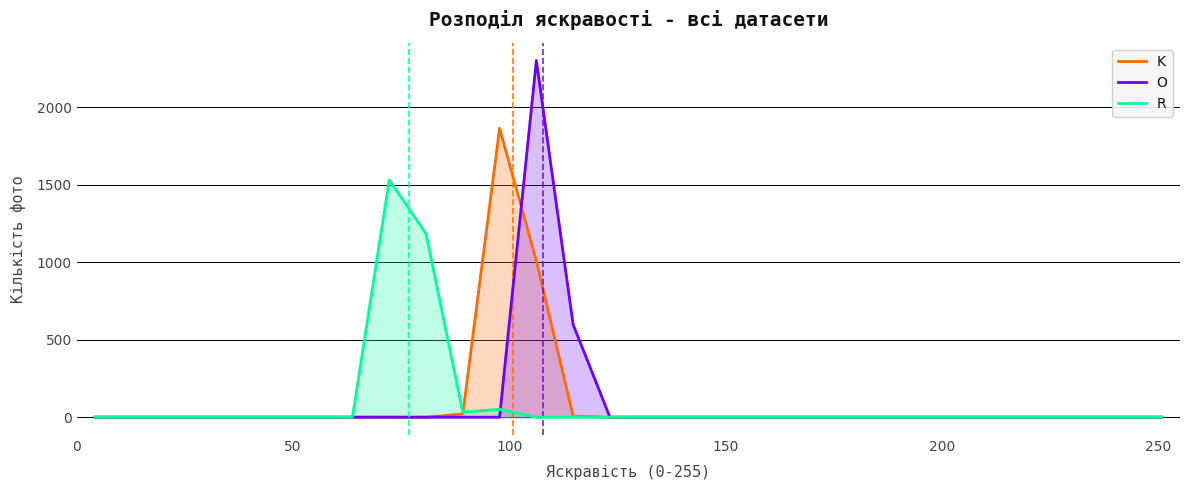

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

for name, d in data.items():
    counts, edges = np.histogram(d["brightness"], bins=30, range=(0, 255))
    centers = (edges[:-1] + edges[1:]) / 2

    ax.fill_between(centers, counts, alpha=0.25, color=colors[name])
    ax.plot(centers, counts, color=colors[name], linewidth=2, label=name)
    ax.axvline(
        d["brightness"].mean(),
        color=colors[name],
        linewidth=1.2,
        linestyle="--",
        alpha=0.9,
    )

ax.set_xlim(0, 255)
ax.yaxis.grid(True, color="#00000015", linewidth=0.7)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(colors="#444444", labelsize=10, length=0)
ax.set_xlabel(
    "Яскравість (0-255)",
    color="#444444",
    fontsize=11,
    fontfamily="monospace",
    labelpad=8,
)
ax.set_ylabel(
    "Кількість фото",
    color="#444444",
    fontsize=11,
    fontfamily="monospace",
    labelpad=8,
)
ax.set_title(
    "Розподіл яскравості - всі датасети",
    color="#111111",
    fontsize=14,
    fontweight="bold",
    fontfamily="monospace",
    pad=12,
)
ax.legend(
    facecolor="#f5f5f5",
    edgecolor="#cccccc",
    labelcolor="#111111",
    fontsize=10,
    framealpha=0.9,
)

plt.tight_layout()
plt.show()

### Joint metric stats

In [29]:
def analyze_image_quality(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w  = gray.shape

    # Sharpness — Laplacian variance (higher = sharper)
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Brightness — mean of grayscale
    brightness = np.mean(gray)

    # Contrast — std of grayscale
    contrast = np.std(gray)

    # Noise estimate — mean absolute diff from blurred version
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    noise = np.mean(np.abs(gray.astype(np.float32) - blurred.astype(np.float32)))

    # Overexposed pixels (>250) and underexposed (<5) as % of image
    total_px = h * w
    overexposed  = np.sum(gray > 250) / total_px * 100
    underexposed = np.sum(gray < 5)   / total_px * 100

    # Resolution
    resolution = h * w

    return {
        "sharpness":    sharpness,
        "brightness":   brightness,
        "contrast":     contrast,
        "noise":        noise,
        "overexposed":  overexposed,
        "underexposed": underexposed,
        "resolution":   resolution,
        "width":        w,
        "height":       h,
    }


def load_quality_data(folder):
    records = []
    for label in sorted(os.listdir(folder)):
        label_path = os.path.join(folder, label)
        if not os.path.isdir(label_path):
            continue
        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)
            metrics  = analyze_image_quality(img_path)
            if metrics:
                metrics["label"] = label
                records.append(metrics)
    return records


quality_data = {}
for name, path in datasets.items():
    records = load_quality_data(path)
    quality_data[name] = records
    n = len(records)

    sharpness  = np.mean([r["sharpness"]   for r in records])
    brightness = np.mean([r["brightness"]  for r in records])
    contrast   = np.mean([r["contrast"]    for r in records])
    noise      = np.mean([r["noise"]       for r in records])
    overexp    = np.mean([r["overexposed"] for r in records])
    underexp   = np.mean([r["underexposed"]for r in records])
    res        = np.mean([r["resolution"]  for r in records])

    print(f"\n{'─'*46}")
    print(f"  {name}  ({n} фото)")
    print(f"{'─'*46}")
    print(f"  Різкість (Laplacian var) : {sharpness:>8.1f}")
    print(f"  Яскравість (середня)     : {brightness:>8.1f}  /255")
    print(f"  Контраст (std)           : {contrast:>8.1f}")
    print(f"  Шум (blur diff)          : {noise:>8.2f}")
    print(f"  Засвічені пікселі        : {overexp:>8.2f} %")
    print(f"  Затемнені пікселі        : {underexp:>8.2f} %")
    print(f"  Середня роздільність     : {res:>8.0f} px²")


──────────────────────────────────────────────
  K  (2900 фото)
──────────────────────────────────────────────
  Різкість (Laplacian var) :    170.8
  Яскравість (середня)     :    100.9  /255
  Контраст (std)           :     53.3
  Шум (blur diff)          :     1.45
  Засвічені пікселі        :     0.13 %
  Затемнені пікселі        :     0.00 %
  Середня роздільність     :   480000 px²

──────────────────────────────────────────────
  O  (2900 фото)
──────────────────────────────────────────────
  Різкість (Laplacian var) :     31.8
  Яскравість (середня)     :    107.9  /255
  Контраст (std)           :     68.2
  Шум (blur diff)          :     0.92
  Засвічені пікселі        :     0.00 %
  Затемнені пікселі        :     2.25 %
  Середня роздільність     :  2073600 px²

──────────────────────────────────────────────
  R  (2800 фото)
──────────────────────────────────────────────
  Різкість (Laplacian var) :     47.8
  Яскравість (середня)     :     76.7  /255
  Контраст (std)      

In [30]:
 METRICS = {
    "sharpness":    "Різкість",
    "contrast":     "Контраст",
    "noise":        "Шум",
    "overexposed":  "Засвічені пікс. %",
    "underexposed": "Затемнені пікс. %",
}

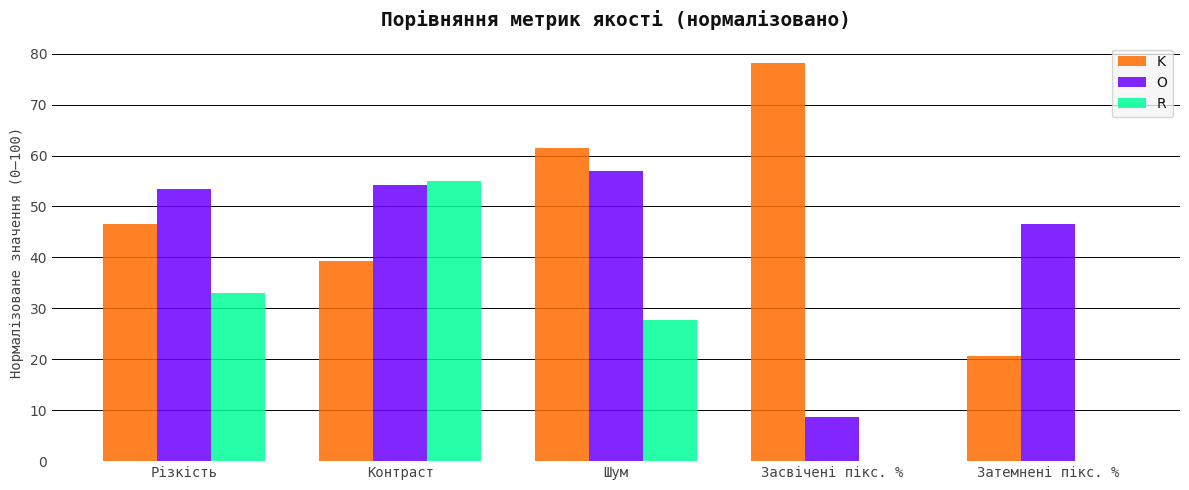

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

metric_keys   = list(METRICS.keys())
metric_labels = list(METRICS.values())
n_metrics = len(metric_keys)
x = np.arange(n_metrics)
width = 0.25

for i, name in enumerate(datasets):
    records = quality_data[name]
    means = []
    for mk in metric_keys:
        vals = [r[mk] for r in records]
        arr = np.array(vals)
        norm = (arr - arr.min()) / (arr.max() - arr.min() + 1e-9) * 100
        means.append(norm.mean())

    bars = ax.bar(x + i * width, means, width=width,
                  color=colors[name], alpha=0.85, label=name)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels, color="#444444",
                   fontsize=10, fontfamily="monospace")
ax.set_ylabel("Нормалізоване значення (0–100)",
              color="#444444", fontfamily="monospace")
ax.set_title("Порівняння метрик якості (нормалізовано)",
             color="#111111", fontsize=14, fontweight="bold",
             fontfamily="monospace", pad=12)
ax.legend(facecolor="#f5f5f5", edgecolor="#cccccc",
          labelcolor="#111111", fontsize=10)
ax.yaxis.grid(True, color="#00000015", linewidth=0.7)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors="#444444", length=0)

plt.tight_layout()
plt.show()


In [32]:
metric_info = {
    "sharpness": {
        "title": "Розподіл різкості - всі датасети",
        "xlabel": "Різкість (Laplacian variance)",
        "bins": 40,
    },
    "brightness": {
        "title": "Розподіл яскравості - всі датасети",
        "xlabel": "Яскравість (0-255)",
        "bins": 30,
        "range": (0, 255),
    },
    "contrast": {
        "title": "Розподіл контрасту - всі датасети",
        "xlabel": "Контраст (std grayscale)",
        "bins": 40,
    },
    "noise": {
        "title": "Розподіл шуму - всі датасети",
        "xlabel": "Шум (mean absolute blur diff)",
        "bins": 40,
    },
    "overexposed": {
        "title": "Розподіл засвічених пікселів - всі датасети",
        "xlabel": "Засвічені пікселі (%)",
        "bins": 30,
    },
    "underexposed": {
        "title": "Розподіл затемнених пікселів - всі датасети",
        "xlabel": "Затемнені пікселі (%)",
        "bins": 30,
    },
    "resolution": {
        "title": "Розподіл роздільності - всі датасети",
        "xlabel": "Роздільність (px^2)",
        "bins": 20,
    },
    "width": {
        "title": "Розподіл ширини зображень - всі датасети",
        "xlabel": "Ширина (px)",
        "bins": 20,
    },
    "height": {
        "title": "Розподіл висоти зображень - всі датасети",
        "xlabel": "Висота (px)",
        "bins": 20,
    },
}

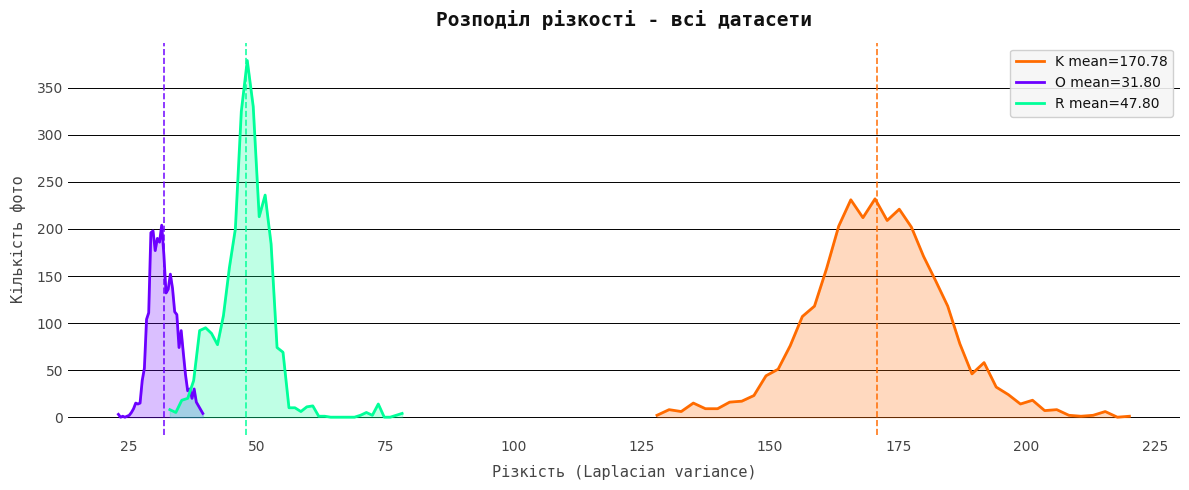

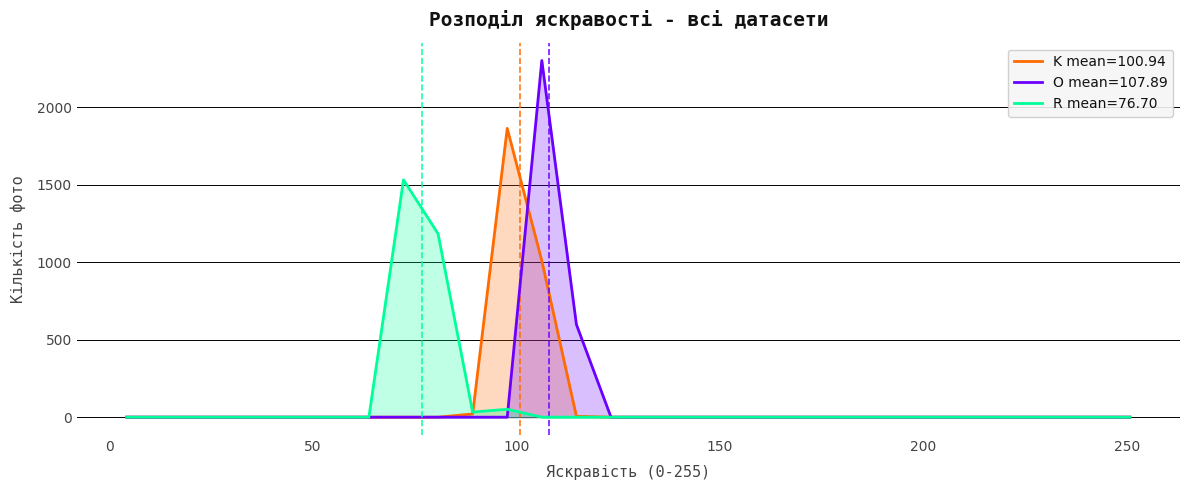

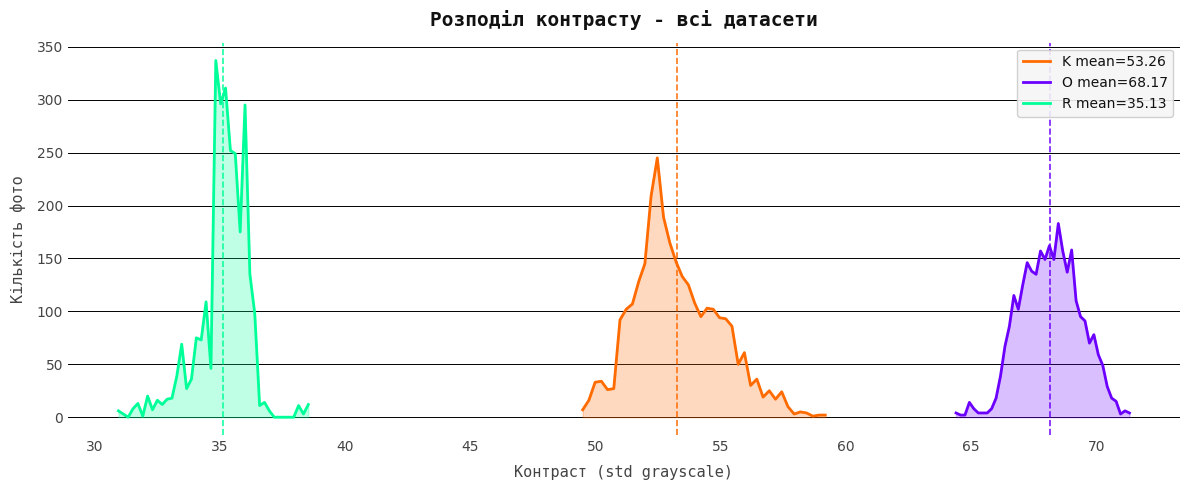

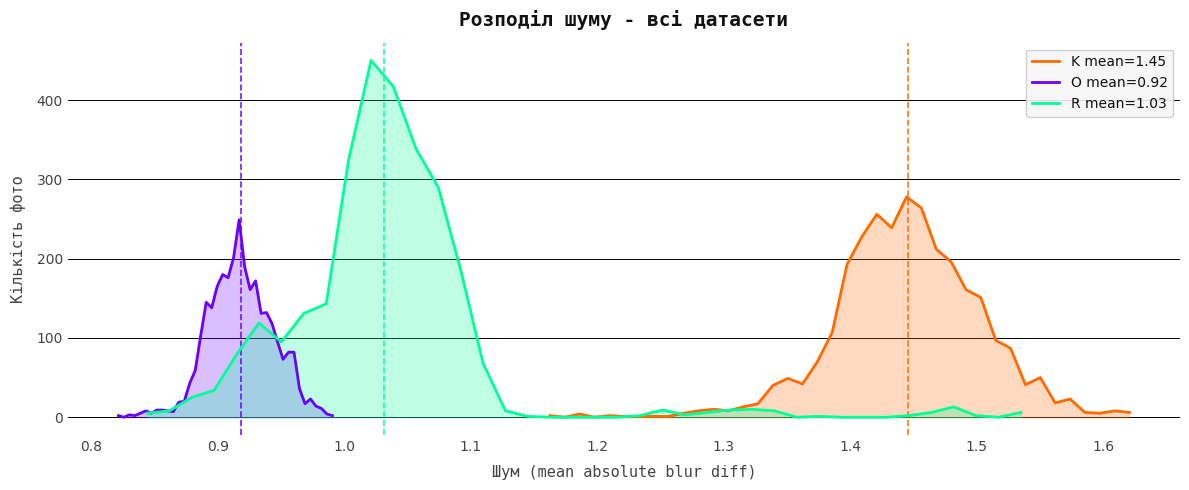

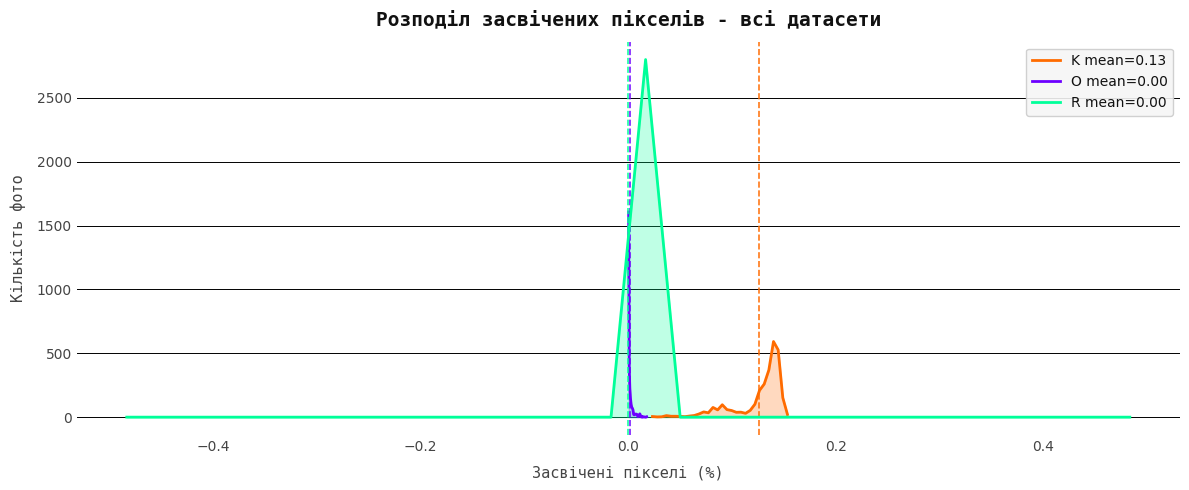

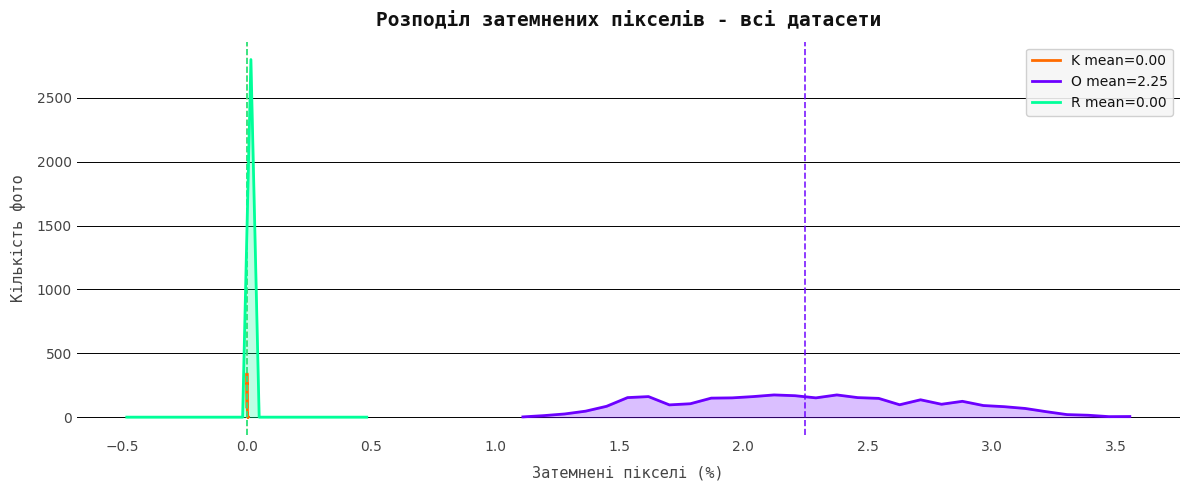

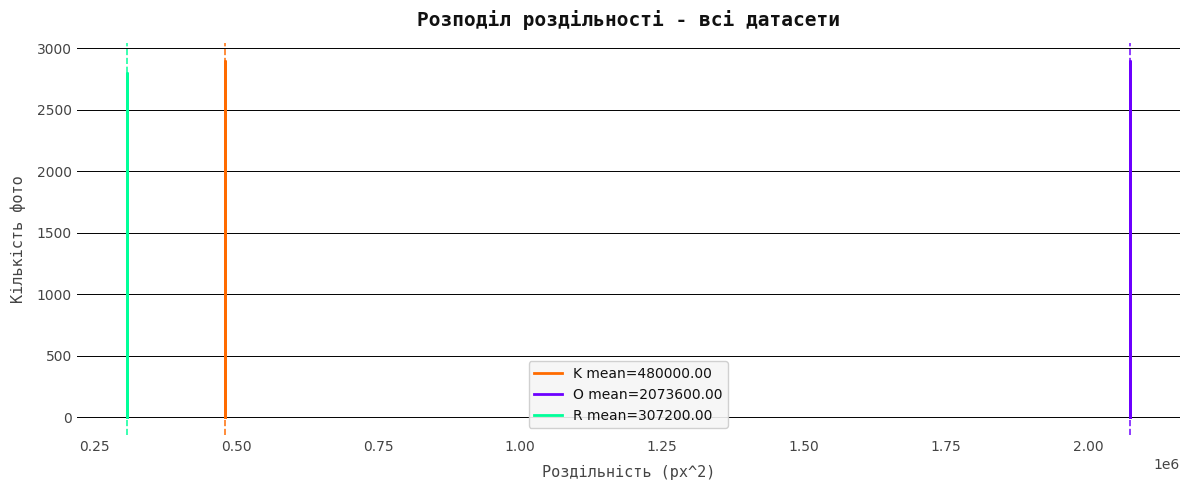

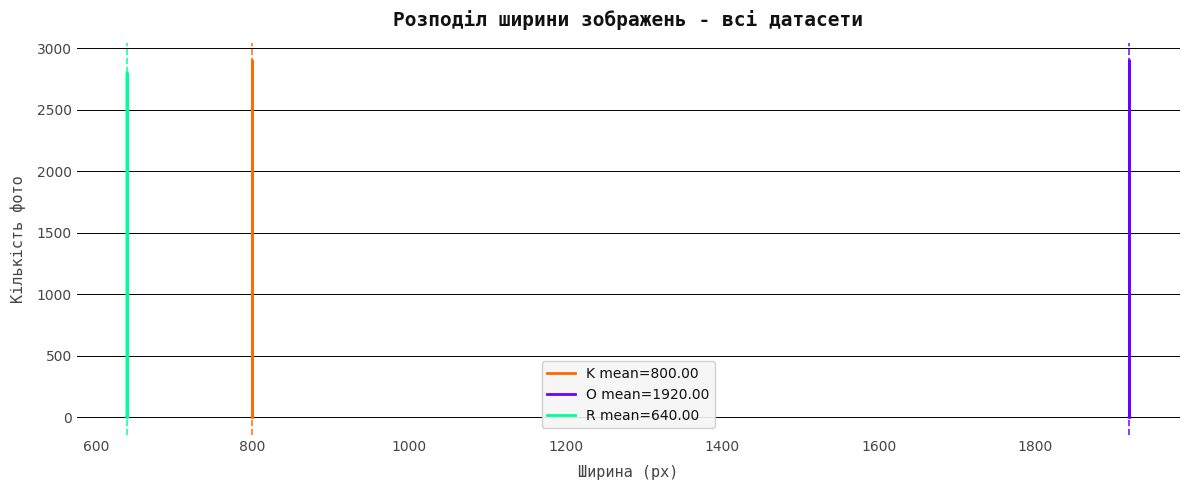

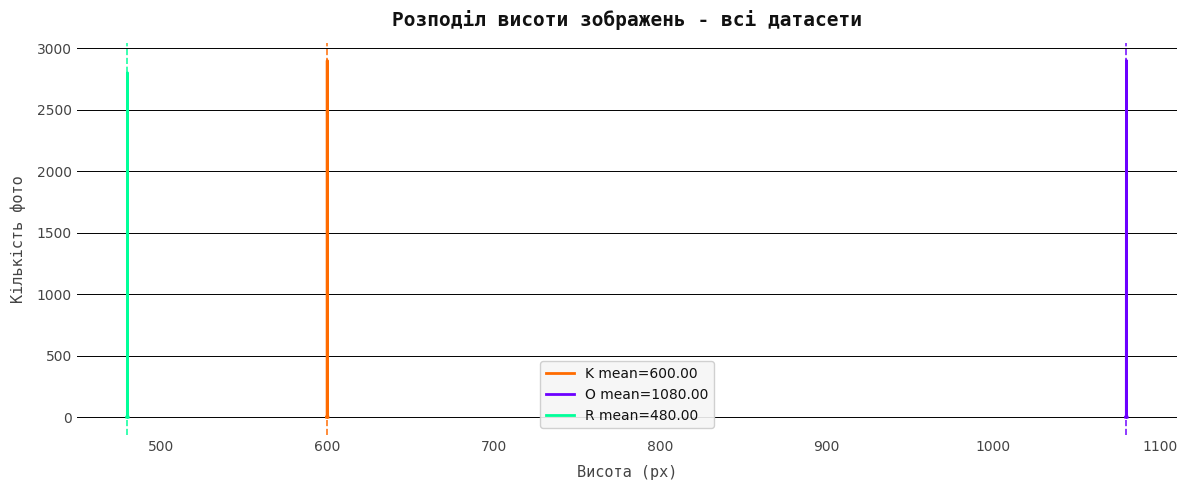

In [33]:
def plot_metric(metric):
    info = metric_info[metric]
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor("#ffffff")
    ax.set_facecolor("#ffffff")

    all_values = np.concatenate([
        np.array([r[metric] for r in records], dtype=float)
        for records in quality_data.values()
        if records
    ])

    hist_range = info.get("range")
    if hist_range is None and np.min(all_values) == np.max(all_values):
        value = float(all_values[0])
        padding = max(abs(value) * 0.05, 1.0)
        hist_range = (value - padding, value + padding)

    for name, records in quality_data.items():
        values = np.array([r[metric] for r in records], dtype=float)
        counts, edges = np.histogram(values, bins=info["bins"], range=hist_range)
        centers = (edges[:-1] + edges[1:]) / 2

        ax.fill_between(centers, counts, alpha=0.25, color=colors[name])
        ax.plot(centers, counts, color=colors[name], linewidth=2, label=f"{name} mean={values.mean():.2f}")
        ax.axvline(values.mean(), color=colors[name], linewidth=1.2, linestyle="--", alpha=0.9)

    ax.yaxis.grid(True, color="#00000015", linewidth=0.7)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(colors="#444444", labelsize=10, length=0)
    ax.set_xlabel(info["xlabel"], color="#444444", fontsize=11, fontfamily="monospace", labelpad=8)
    ax.set_ylabel("Кількість фото", color="#444444", fontsize=11, fontfamily="monospace", labelpad=8)
    ax.set_title(info["title"], color="#111111", fontsize=14, fontweight="bold", fontfamily="monospace", pad=12)
    ax.legend(facecolor="#f5f5f5", edgecolor="#cccccc", labelcolor="#111111", fontsize=10, framealpha=0.9)

    plt.tight_layout()
    plt.show()


for metric in metric_info:
    plot_metric(metric)

# Keypoint visualization

In [50]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [34]:
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

In [35]:
def get_sample_images(folder, n_samples=6):
    samples = []
    for label in sorted(os.listdir(folder)):
        label_path = os.path.join(folder, label)
        if not os.path.isdir(label_path):
            continue
        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                samples.append((img, label))
                break 
        if len(samples) >= n_samples:
            break
    return samples

In [36]:
def draw_landmarks_on_image(img):
    img_draw = img.copy()
    blank   = np.zeros_like(img)

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=2,
        min_detection_confidence=0.3
    ) as hands:
        results = hands.process(img)

    detected = False

    if results.multi_hand_landmarks:
        detected = True
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                img_draw,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style(),
            )
            mp_drawing.draw_landmarks(
                blank,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(0, 255, 180), thickness=3, circle_radius=4),
                mp_drawing.DrawingSpec(color=(255, 100, 0), thickness=2),
            )

    return img, img_draw, blank, detected

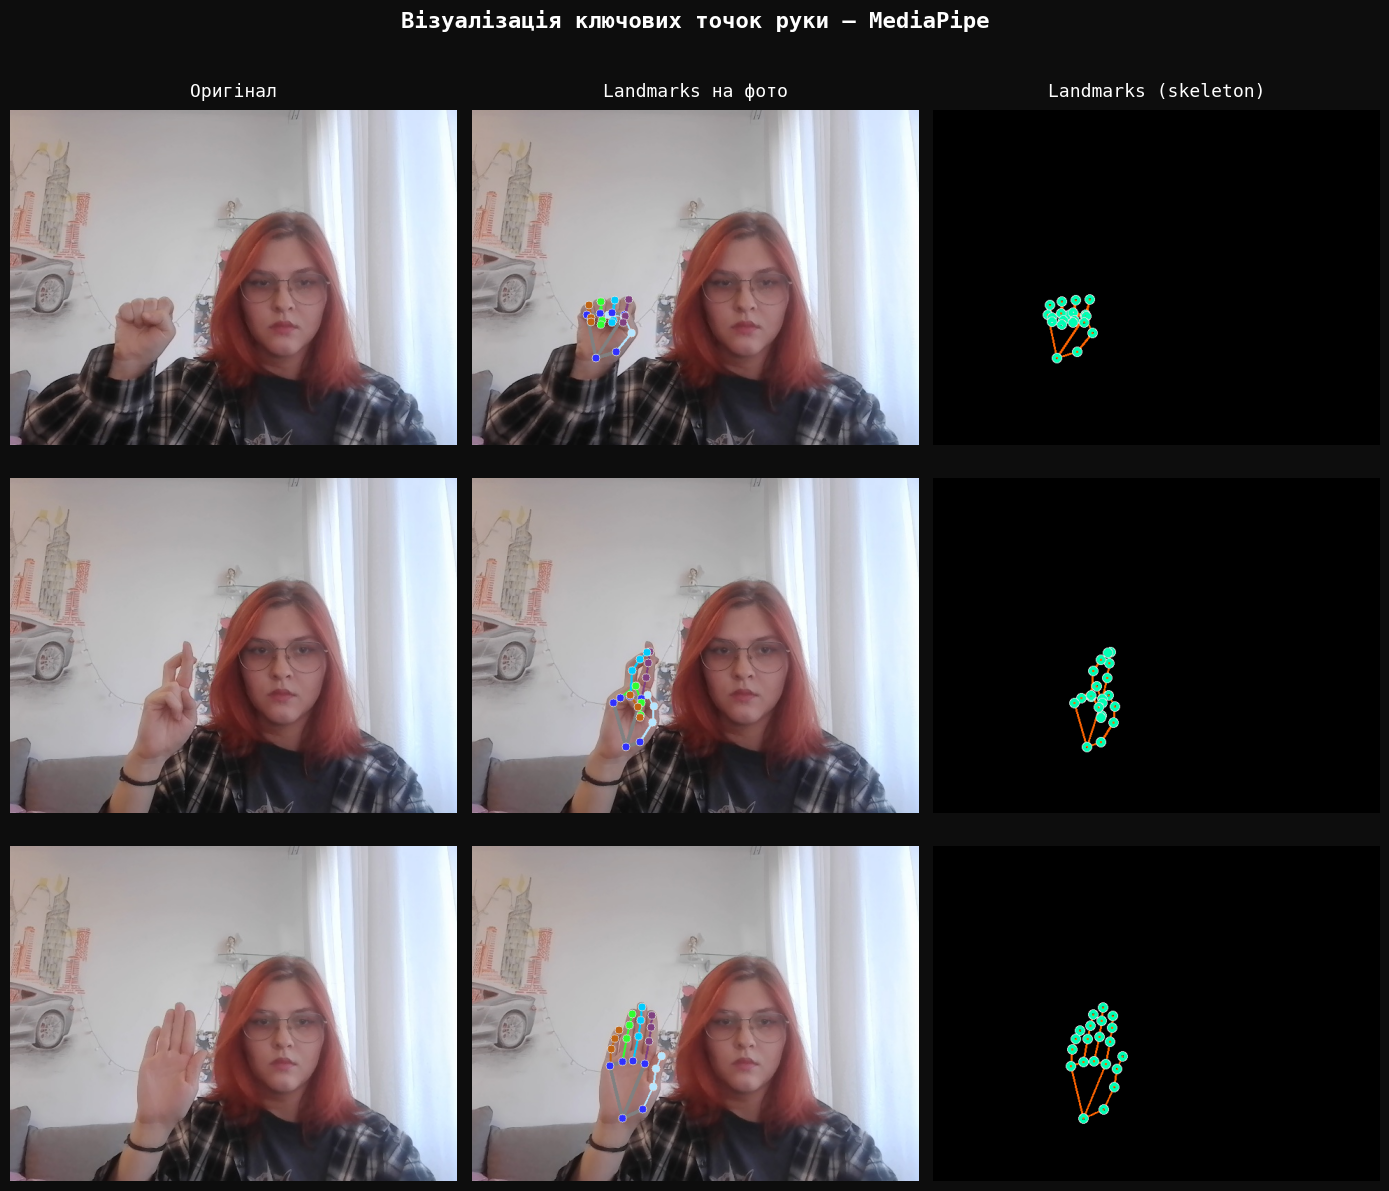

In [ ]:
samples = get_sample_images(DATASET_Display, n_samples=3)

n = len(samples)
fig, axes = plt.subplots(n, 3, figsize=(14, 4 * n))
fig.patch.set_facecolor("#0d0d0d")

col_titles = ["Оригінал", "Landmarks на фото", "Landmarks (skeleton)"]
for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, color="#ffffff", fontsize=13,
                           fontfamily="monospace", pad=10)

for row, (img, label) in enumerate(samples):
    original, with_landmarks, skeleton, detected = draw_landmarks_on_image(img)

    status = "✓ знайдено" if detected else "✗ не знайдено"
    status_color = "#00FF99" if detected else "#FF4444"

    for col, frame in enumerate([original, with_landmarks, skeleton]):
        ax = axes[row][col]
        ax.imshow(frame)
        ax.set_facecolor("#0d0d0d")
        ax.axis("off")

        if col == 0:
            ax.set_ylabel(f"[{label}]  {status}", color=status_color,
                          fontsize=10, fontfamily="monospace", rotation=0,
                          labelpad=120, va="center")

fig.suptitle("Візуалізація ключових точок руки — MediaPipe",
             color="#ffffff", fontsize=16, fontweight="bold",
             fontfamily="monospace", y=1.01)

plt.tight_layout()
plt.show()

In [44]:
pickle_data = {}

for name, path in pickle_files.items():
    with open(path, "rb") as f:
        raw = pickle.load(f)

    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  Тип:     {type(raw)}")

    if isinstance(raw, dict):
        print(f"  Ключі:   {list(raw.keys())}")
        for k, v in raw.items():
            sample = v[:2] if hasattr(v, '__iter__') else v
            print(f"    [{k}] → тип: {type(v).__name__}, "
                  f"довжина: {len(v) if hasattr(v, '__len__') else '—'}, "
                  f"зразок: {sample}")
    elif isinstance(raw, (list, tuple)):
        print(f"  Довжина: {len(raw)}")
        print(f"  Зразок[0]: {raw[0]}")

    pickle_data[name] = raw


──────────────────────────────────────────────────
  K
──────────────────────────────────────────────────
  Тип:     <class 'dict'>
  Ключі:   ['data', 'labels']
    [data] → тип: list, довжина: 2592, зразок: [[0.014504760503768921, 0.20356464385986328, 0.06806007027626038, 0.19206279516220093, 0.11116188764572144, 0.14394664764404297, 0.10885286331176758, 0.0829833447933197, 0.07858335971832275, 0.05383753776550293, 0.09432101249694824, 0.07939410209655762, 0.11238163709640503, 0.023246049880981445, 0.10114774107933044, 0.06592851877212524, 0.09088224172592163, 0.09659752249717712, 0.06438925862312317, 0.06345734000205994, 0.08248329162597656, 0.006213545799255371, 0.0717591941356659, 0.062045156955718994, 0.060657382011413574, 0.09901952743530273, 0.033793866634368896, 0.05706945061683655, 0.050750404596328735, 0.0, 0.0459713339805603, 0.05925297737121582, 0.03657832741737366, 0.10022172331809998, 0.0, 0.05740600824356079, 0.016801655292510986, 0.015605658292770386, 0.02002111077308

In [45]:
parsed = {}

for name, raw in pickle_data.items():
    if isinstance(raw, dict):
        raw_features = raw.get("data", raw.get("features", []))
        labels       = np.array(raw.get("labels", raw.get("label", [])))
    else:
        raw_features, labels = raw[0], raw[1]
        labels = np.array(labels)

    lengths = [len(f) for f in raw_features]
    max_len = max(lengths)
    min_len = min(lengths)

    if max_len != min_len:
        print(f"[{name}] Нерівномірні ознаки: "
              f"мін={min_len}, макс={max_len} — падінг до {max_len}")
        features = np.array([
            np.pad(np.array(f, dtype=np.float32),
                   (0, max_len - len(f))) for f in raw_features
        ])
    else:
        features = np.array(raw_features, dtype=np.float32)

    valid_mask = features.sum(axis=1) != 0
    n_dropped  = np.sum(~valid_mask)
    if n_dropped:
        print(f"[{name}] Відкинуто {n_dropped} порожніх зразків")
        features = features[valid_mask]
        labels   = labels[valid_mask]

    parsed[name] = {"features": features, "labels": labels}

    classes    = sorted(set(labels))
    all_possible = sorted(set(
        lbl for d in parsed.values() for lbl in d["labels"]
    ))
    missing = [c for c in all_possible if c not in classes]

    print(f"\n[{name}]  {len(labels)} зразків | "
          f"{len(classes)} класів | "
          f"форма: {features.shape}")
    print(f"  Класи: {classes}")
    if missing:
        print(f"  Відсутні класи: {missing}")

[K] Нерівномірні ознаки: мін=42, макс=84 — падінг до 84

[K]  2592 зразків | 29 класів | форма: (2592, 84)
  Класи: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '3', '4', '5', '6', '7', '8', '9']
[O] Нерівномірні ознаки: мін=42, макс=84 — падінг до 84

[O]  2900 зразків | 29 класів | форма: (2900, 84)
  Класи: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '3', '4', '5', '6', '7', '8', '9']
[R] Нерівномірні ознаки: мін=42, макс=84 — падінг до 84

[R]  1761 зразків | 28 класів | форма: (1761, 84)
  Класи: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '3', '4', '5', '6', '7', '8', '9']
  Відсутні класи: ['28']


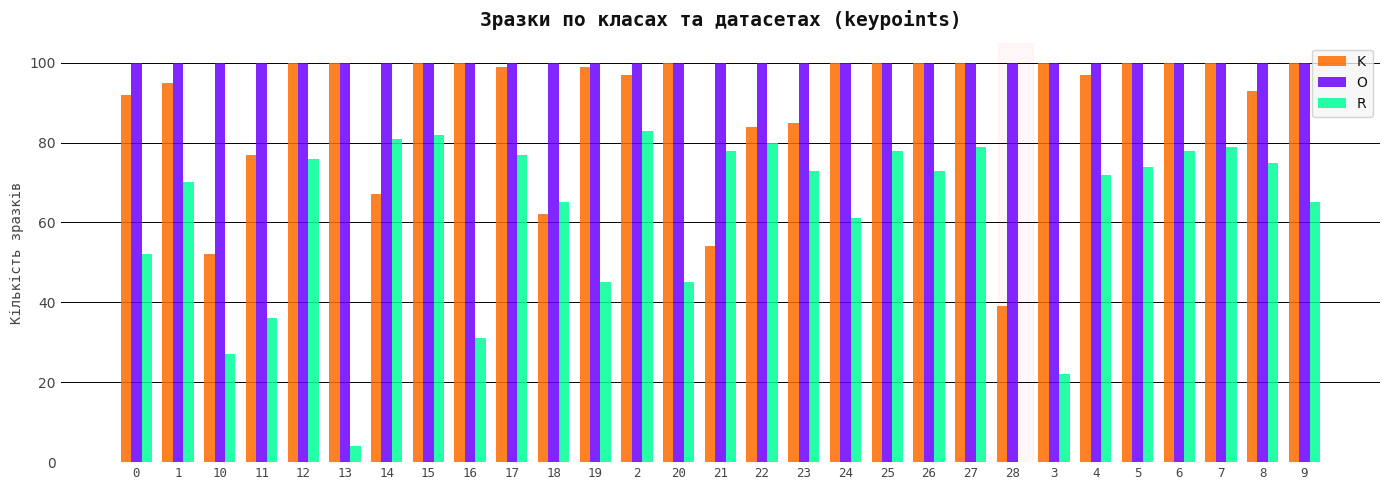

In [46]:
all_classes = sorted(set(
    lbl for d in parsed.values() for lbl in d["labels"]
))

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

x     = np.arange(len(all_classes))
width = 0.25

for i, (name, d) in enumerate(parsed.items()):
    counts = [np.sum(d["labels"] == c) for c in all_classes]
    bars   = ax.bar(x + i * width, counts, width=width,
                    color=colors[name], alpha=0.85, label=name)

for j, cls in enumerate(all_classes):
    any_missing = any(
        np.sum(d["labels"] == cls) == 0 for d in parsed.values()
    )
    if any_missing:
        ax.axvspan(j - 0.1, j + 0.75, color="#ff000008", zorder=0)

ax.set_xticks(x + width)
ax.set_xticklabels(all_classes, color="#444444",
                   fontsize=9, fontfamily="monospace")
ax.set_ylabel("Кількість зразків", color="#444444", fontfamily="monospace")
ax.set_title("Зразки по класах та датасетах (keypoints)",
             color="#111111", fontsize=14, fontweight="bold",
             fontfamily="monospace", pad=12)
ax.legend(facecolor="#f5f5f5", edgecolor="#cccccc",
          labelcolor="#111111", fontsize=10)
ax.yaxis.grid(True, color="#00000015", linewidth=0.7)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors="#444444", length=0)
plt.tight_layout()
plt.show()

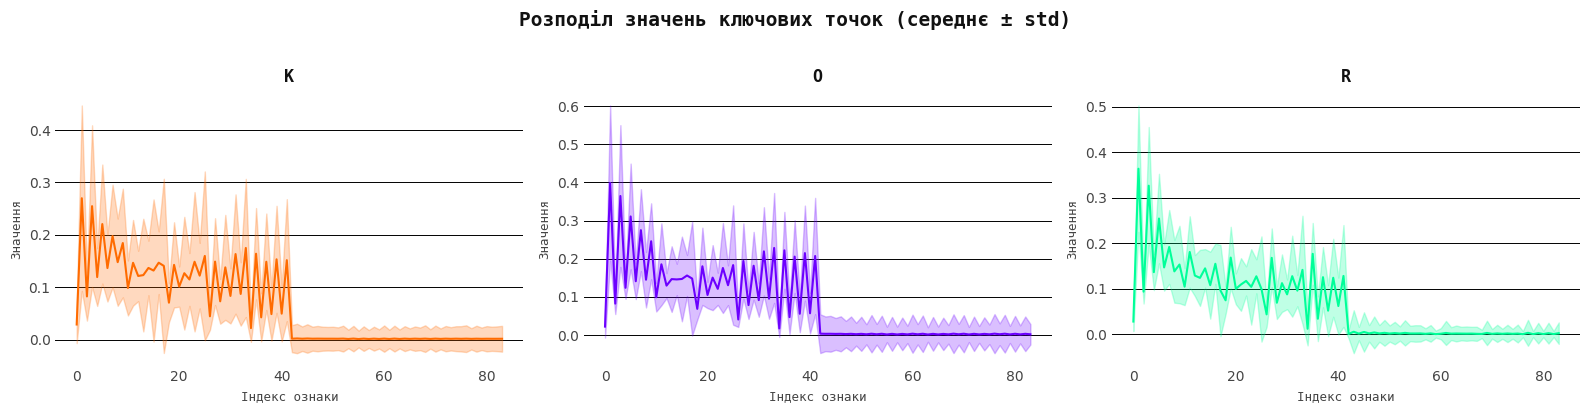

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor("#ffffff")

for ax, (name, d) in zip(axes, parsed.items()):
    ax.set_facecolor("#ffffff")
    features = d["features"]

    mean_per_feat = features.mean(axis=0)
    std_per_feat  = features.std(axis=0)
    feat_idx      = np.arange(len(mean_per_feat))

    ax.fill_between(feat_idx,
                    mean_per_feat - std_per_feat,
                    mean_per_feat + std_per_feat,
                    alpha=0.25, color=colors[name])
    ax.plot(feat_idx, mean_per_feat, color=colors[name],
            linewidth=1.5, label="середнє")

    ax.set_title(name, color="#111111", fontsize=12,
                 fontweight="bold", fontfamily="monospace", pad=8)
    ax.set_xlabel("Індекс ознаки", color="#444444",
                  fontfamily="monospace", fontsize=9)
    ax.set_ylabel("Значення", color="#444444",
                  fontfamily="monospace", fontsize=9)
    ax.yaxis.grid(True, color="#00000012", linewidth=0.7)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors="#444444", length=0)

fig.suptitle("Розподіл значень ключових точок (середнє ± std)",
             color="#111111", fontsize=14, fontweight="bold",
             fontfamily="monospace", y=1.02)
plt.tight_layout()
plt.show()

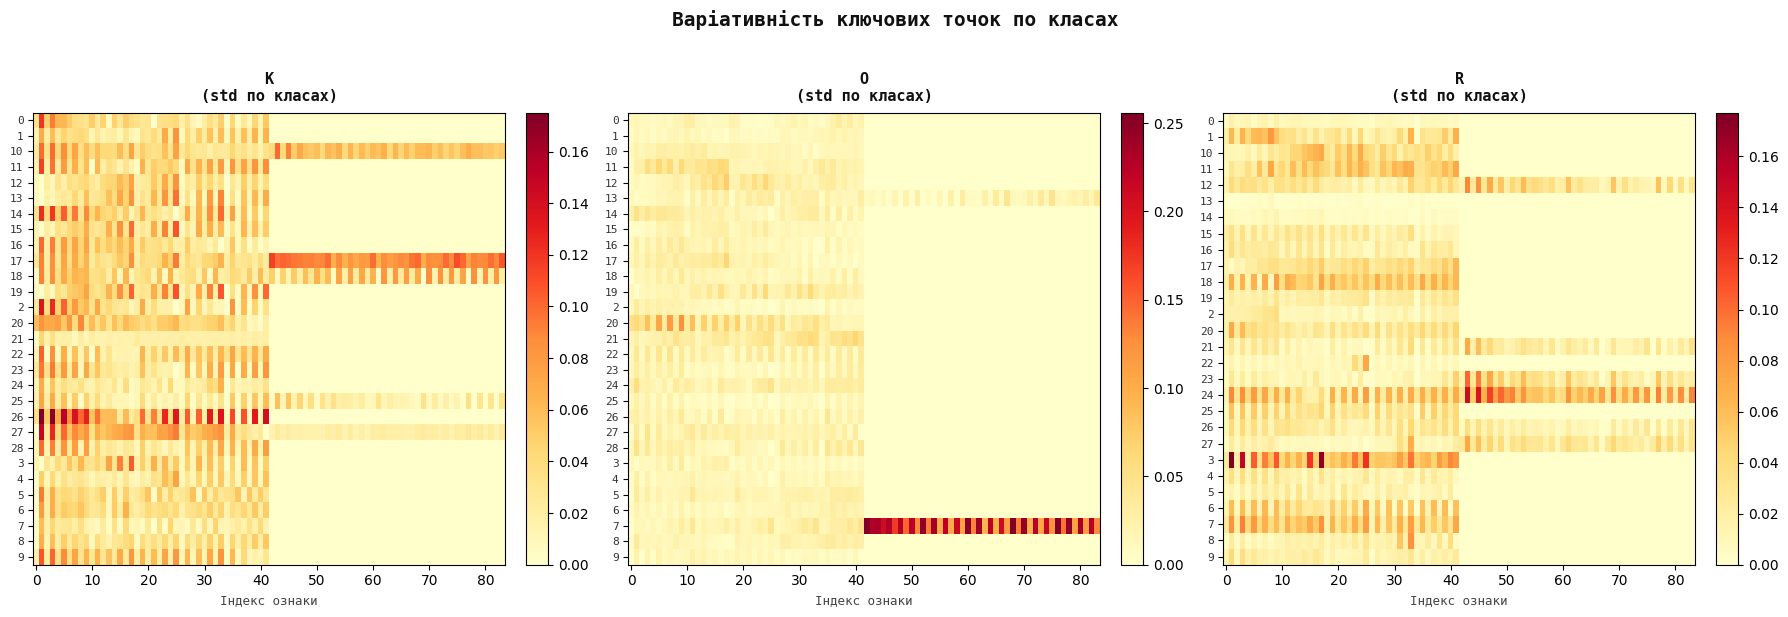

In [49]:
fig, axes = plt.subplots(1, len(parsed), figsize=(18, 6))
fig.patch.set_facecolor("#ffffff")

for ax, (name, d) in zip(axes, parsed.items()):
    classes  = sorted(set(d["labels"]))
    features = d["features"]
    labels   = d["labels"]

    matrix = []
    for cls in classes:
        mask    = labels == cls
        cls_std = features[mask].std(axis=0) if mask.sum() > 1 else np.zeros(features.shape[1])
        matrix.append(cls_std)

    matrix = np.array(matrix)

    im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd",
                   interpolation="nearest")
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes, fontsize=8,
                       color="#333333", fontfamily="monospace")
    ax.set_xlabel("Індекс ознаки", color="#444444",
                  fontfamily="monospace", fontsize=9)
    ax.set_title(f"{name}\n(std по класах)",
                 color="#111111", fontsize=11,
                 fontweight="bold", fontfamily="monospace", pad=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Варіативність ключових точок по класах",
             color="#111111", fontsize=14, fontweight="bold",
             fontfamily="monospace", y=1.02)
plt.tight_layout()
plt.show()

In [51]:
all_features = np.vstack([d["features"] for d in parsed.values()])
all_labels   = np.concatenate([d["labels"]   for d in parsed.values()])
all_sources  = np.concatenate([
    np.array([name] * len(d["labels"])) for name, d in parsed.items()
])

scaler      = StandardScaler()
all_scaled  = scaler.fit_transform(all_features)

print(f"Загалом: {len(all_labels)} зразків | "
      f"{all_features.shape[1]} ознак | "
      f"{len(set(all_labels))} класів")

Загалом: 7253 зразків | 84 ознак | 29 класів


PCA поясненa дисперсія: PC1=46.2%  PC2=13.5%  разом=59.6%


C:\Users\Kate\AppData\Local\Temp\ipykernel_39488\2127518405.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  class_cmap     = plt.cm.get_cmap("tab20", len(unique_classes))


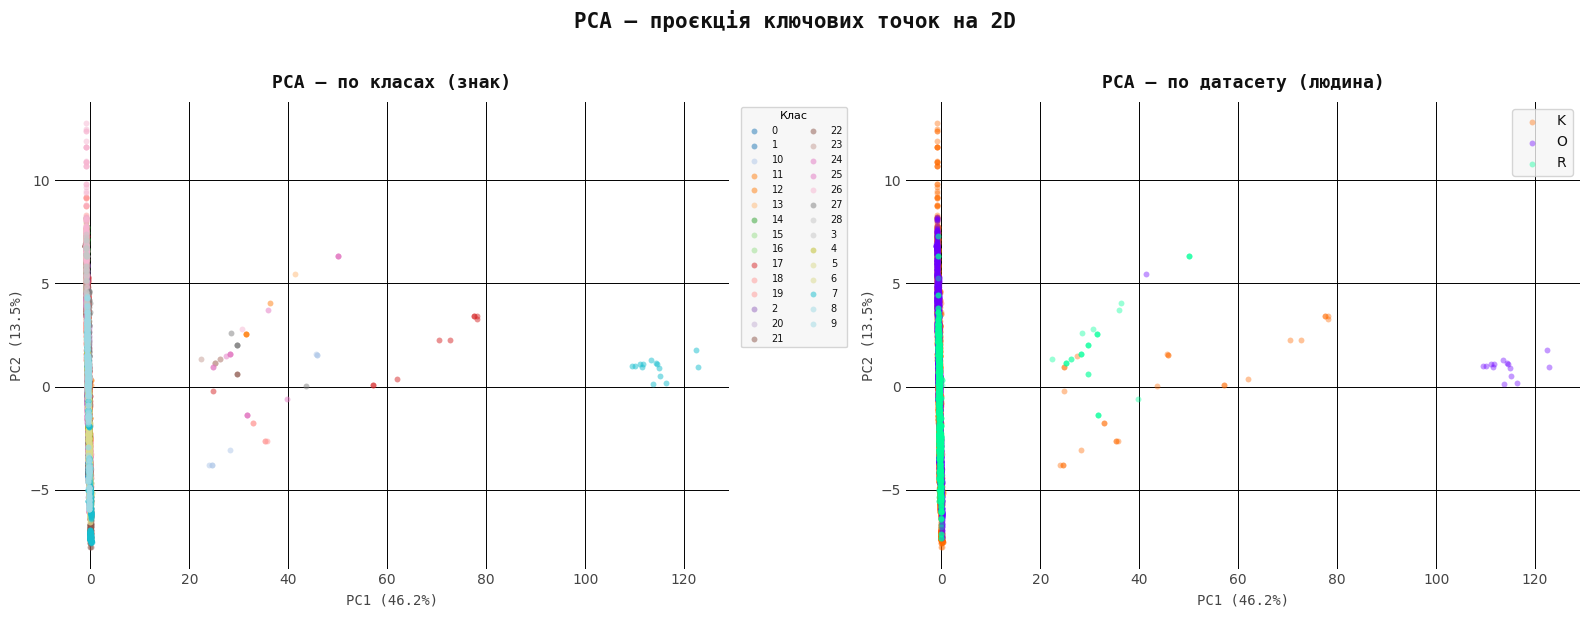

In [ ]:
pca        = PCA(n_components=2)
pca_result = pca.fit_transform(all_scaled)

print(f"PCA поясненa дисперсія: "
      f"PC1={pca.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%  "
      f"разом={sum(pca.explained_variance_ratio_)*100:.1f}%")

unique_classes = sorted(set(all_labels))
class_cmap     = plt.cm.get_cmap("tab20", len(unique_classes))
class_color    = {cls: class_cmap(i) for i, cls in enumerate(unique_classes)}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#ffffff")

# Left — colored by CLASS
ax = axes[0]
ax.set_facecolor("#ffffff")
for cls in unique_classes:
    mask = all_labels == cls
    ax.scatter(pca_result[mask, 0], pca_result[mask, 1],
               color=class_color[cls], alpha=0.5, s=18,
               linewidths=0, label=cls)

ax.set_title("PCA — по класах (знак)",
             color="#111111", fontsize=13, fontweight="bold",
             fontfamily="monospace", pad=10)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
              color="#444444", fontfamily="monospace")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
              color="#444444", fontfamily="monospace")
ax.legend(title="Клас", fontsize=7, title_fontsize=8,
          facecolor="#f5f5f5", edgecolor="#cccccc",
          labelcolor="#111111", ncol=2,
          bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.grid(True, color="#00000012", linewidth=0.7)
ax.xaxis.grid(True, color="#00000012", linewidth=0.7)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors="#444444", length=0)

ax = axes[1]
ax.set_facecolor("#ffffff")
for name in parsed:
    mask = all_sources == name
    ax.scatter(pca_result[mask, 0], pca_result[mask, 1],
               color=colors[name], alpha=0.4, s=18,
               linewidths=0, label=name)

ax.set_title("PCA — по датасету (людина)",
             color="#111111", fontsize=13, fontweight="bold",
             fontfamily="monospace", pad=10)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
              color="#444444", fontfamily="monospace")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
              color="#444444", fontfamily="monospace")
ax.legend(facecolor="#f5f5f5", edgecolor="#cccccc",
          labelcolor="#111111", fontsize=10)
ax.yaxis.grid(True, color="#00000012", linewidth=0.7)
ax.xaxis.grid(True, color="#00000012", linewidth=0.7)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors="#444444", length=0)

plt.suptitle("PCA — проєкція ключових точок на 2D",
             color="#111111", fontsize=15, fontweight="bold",
             fontfamily="monospace", y=1.02)
plt.tight_layout()
plt.show()

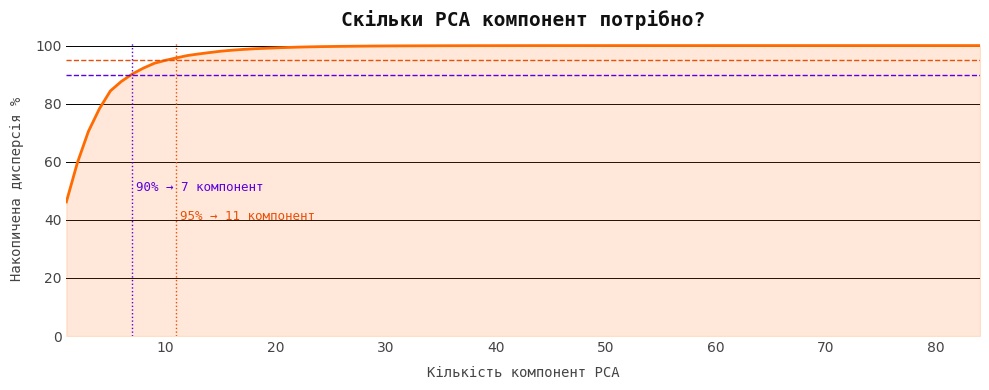

90% дисперсії → 7 компонент
95% дисперсії → 11 компонент
Всього ознак  → 84


In [58]:
pca_full    = PCA().fit(all_scaled)
cumvar      = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_for_90    = np.searchsorted(cumvar, 90) + 1
n_for_95    = np.searchsorted(cumvar, 95) + 1

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

ax.plot(range(1, len(cumvar) + 1), cumvar,
        color=colors["K"], linewidth=2)
ax.fill_between(range(1, len(cumvar) + 1), cumvar,
                alpha=0.15, color=colors["K"])

ax.axhline(90, color="#5B00E0", linewidth=1, linestyle="--")
ax.axhline(95, color="#E8500A", linewidth=1, linestyle="--")
ax.axvline(n_for_90, color="#5B00E0", linewidth=1, linestyle=":")
ax.axvline(n_for_95, color="#E8500A", linewidth=1, linestyle=":")

ax.text(n_for_90 + 0.3, 50, f"90% → {n_for_90} компонент",
        color="#5B00E0", fontsize=9, fontfamily="monospace")
ax.text(n_for_95 + 0.3, 40, f"95% → {n_for_95} компонент",
        color="#E8500A", fontsize=9, fontfamily="monospace")

ax.set_xlabel("Кількість компонент PCA",
              color="#444444", fontfamily="monospace", labelpad=8)
ax.set_ylabel("Накопичена дисперсія %",
              color="#444444", fontfamily="monospace", labelpad=8)
ax.set_title("Скільки PCA компонент потрібно?",
             color="#111111", fontsize=14, fontweight="bold",
             fontfamily="monospace", pad=12)
ax.set_xlim(1, len(cumvar))
ax.set_ylim(0, 101)
ax.yaxis.grid(True, color="#00000012", linewidth=0.7)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors="#444444", length=0)

plt.tight_layout()
plt.show()

print(f"90% дисперсії → {n_for_90} компонент")
print(f"95% дисперсії → {n_for_95} компонент")
print(f"Всього ознак  → {all_features.shape[1]}")

Запуск t-SNE... (може зайняти хвилину)
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 7253 samples in 0.000s...
[t-SNE] Computed neighbors for 7253 samples in 4.445s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7253
[t-SNE] Computed conditional probabilities for sample 2000 / 7253
[t-SNE] Computed conditional probabilities for sample 3000 / 7253
[t-SNE] Computed conditional probabilities for sample 4000 / 7253
[t-SNE] Computed conditional probabilities for sample 5000 / 7253
[t-SNE] Computed conditional probabilities for sample 6000 / 7253
[t-SNE] Computed conditional probabilities for sample 7000 / 7253
[t-SNE] Computed conditional probabilities for sample 7253 / 7253
[t-SNE] Mean sigma: 1.063748
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.471531
[t-SNE] KL divergence after 1000 iterations: 0.377659


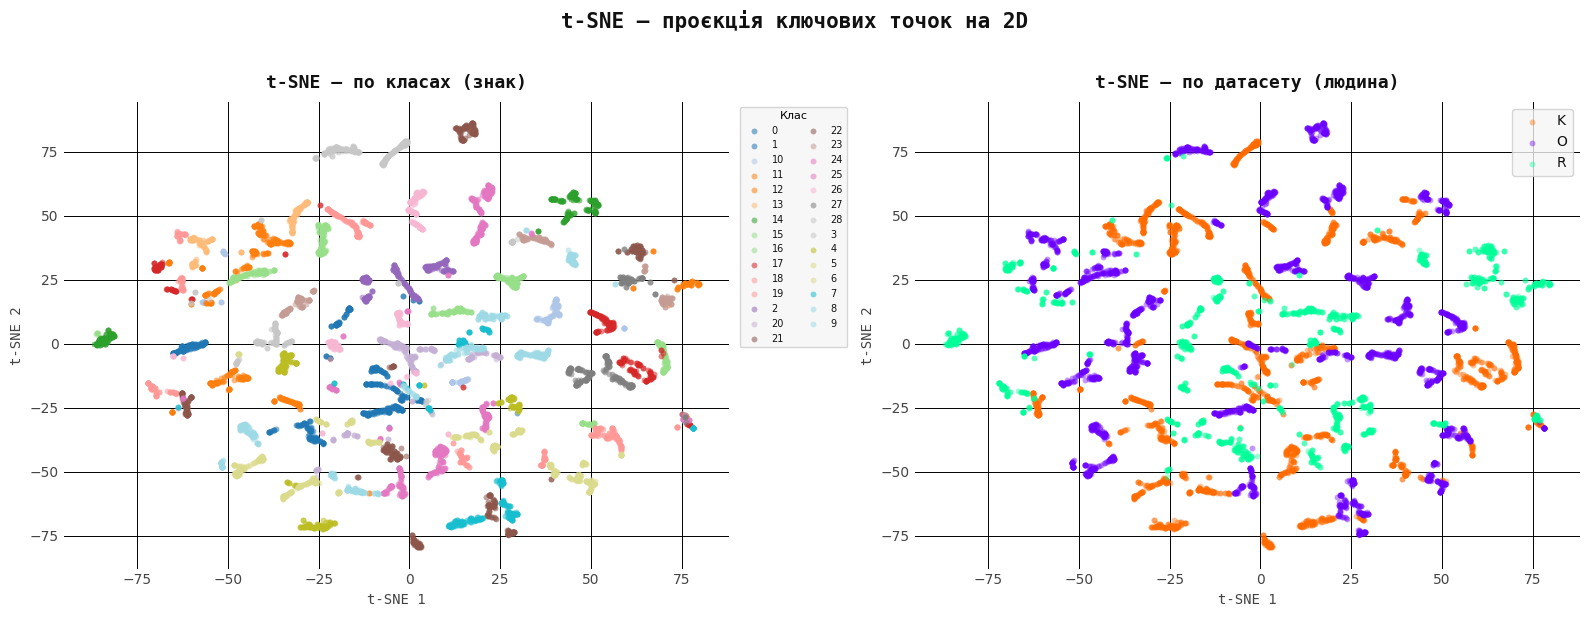

In [59]:
print("Запуск t-SNE... (може зайняти хвилину)")

tsne        = TSNE(n_components=2, perplexity=40, max_iter=1000,
                   random_state=42, verbose=1)
tsne_result = tsne.fit_transform(all_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#ffffff")

ax = axes[0]
ax.set_facecolor("#ffffff")
for cls in unique_classes:
    mask = all_labels == cls
    ax.scatter(tsne_result[mask, 0], tsne_result[mask, 1],
               color=class_color[cls], alpha=0.55, s=18,
               linewidths=0, label=cls)

ax.set_title("t-SNE — по класах (знак)",
             color="#111111", fontsize=13, fontweight="bold",
             fontfamily="monospace", pad=10)
ax.set_xlabel("t-SNE 1", color="#444444", fontfamily="monospace")
ax.set_ylabel("t-SNE 2", color="#444444", fontfamily="monospace")
ax.legend(title="Клас", fontsize=7, title_fontsize=8,
          facecolor="#f5f5f5", edgecolor="#cccccc",
          labelcolor="#111111", ncol=2,
          bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.grid(True, color="#00000012", linewidth=0.7)
ax.xaxis.grid(True, color="#00000012", linewidth=0.7)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors="#444444", length=0)

ax = axes[1]
ax.set_facecolor("#ffffff")
for name in parsed:
    mask = all_sources == name
    ax.scatter(tsne_result[mask, 0], tsne_result[mask, 1],
               color=colors[name], alpha=0.4, s=18,
               linewidths=0, label=name)

ax.set_title("t-SNE — по датасету (людина)",
             color="#111111", fontsize=13, fontweight="bold",
             fontfamily="monospace", pad=10)
ax.set_xlabel("t-SNE 1", color="#444444", fontfamily="monospace")
ax.set_ylabel("t-SNE 2", color="#444444", fontfamily="monospace")
ax.legend(facecolor="#f5f5f5", edgecolor="#cccccc",
          labelcolor="#111111", fontsize=10)
ax.yaxis.grid(True, color="#00000012", linewidth=0.7)
ax.xaxis.grid(True, color="#00000012", linewidth=0.7)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors="#444444", length=0)

plt.suptitle("t-SNE — проєкція ключових точок на 2D",
             color="#111111", fontsize=15, fontweight="bold",
             fontfamily="monospace", y=1.02)
plt.tight_layout()
plt.show()